In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from lerobot.envs.configs import LiberoEnv
from lerobot.envs import close_envs, make_env

### Check DEV States

In [ ]:
DEV_STATES_PATH = (PROJECT_ROOT / "data/eval_init_states/libero_goal_bowl_plate_dev10.npy")
dev_states = np.load(DEV_STATES_PATH,allow_pickle=False)
dev_states.shape

In [19]:
for i in range(dev_states.shape[0]):
    for j in range(i):
        assert np.sum(np.abs(dev_states[i] - dev_states[j])) > 1e-2

print("All developmental states are different!")

All developmental states are different!


In [25]:
LIBERO_SUITE = "libero_goal"
LIBERO_TASK_ID = 8

FPS = 20
MAX_EPISODE_STEPS = 300
EVAL_SEED = 1000

In [28]:
env_cfg = LiberoEnv(
    task=LIBERO_SUITE,
    task_ids=[LIBERO_TASK_ID],

    # Make all temporal assumptions explicit.
    fps=FPS,
    episode_length=MAX_EPISODE_STEPS,

    # Match NVIDIA demonstrations.
    observation_height=256,
    observation_width=256,

    obs_type="pixels_agent_pos",

    init_states=True,
    hard_reset=True,

    # Keep LeRobot's standard names here:
    # image + image2.
    # Our adapter will rename image2 -> wrist_image.
    camera_name_mapping={
        "agentview_image": "image",
        "robot0_eye_in_hand_image": "image2",
    },
)

envs = make_env(
    env_cfg,
    n_envs=1,
    use_async_envs=False,
)

env = envs[LIBERO_SUITE][LIBERO_TASK_ID]

libero_env = env.envs[0]

offcial_init_states = libero_env._init_states.copy()

print("Official init states:",libero_env._init_states.shape)

[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /home/yjc1989/ML/robot-learning-project1/external/lerobot/.venv/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


Creating LIBERO envs | suites=['libero_goal'] | n_envs(per task)=1 | init_states=True
Restricting to task_ids=[8]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Built vec env | suite=libero_goal | task_id=8 | n_envs=1
Official init states: (50, 79)


In [29]:
for i in range(offcial_init_states.shape[0]):
    for j in range(dev_states.shape[0]):
        assert np.sum(np.abs(offcial_init_states[i] - dev_states[j])) > 1e-2
print("All developmental states are different from the official_init_states!")

All developmental states are different from the official_init_states!


In [31]:
offcial_init_states[0]-dev_states[0]

array([ 0.        ,  0.01543739, -0.00991661, -0.01483789,  0.00985793,
        0.01646613, -0.00795325,  0.01164604,  0.        ,  0.        ,
        0.00412969, -0.01628376,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        , -0.01399455,  0.02160434,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.01054773,
       -0.01906955,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.02310411,  0.00421008,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.  

### act_baseline3

In [4]:
PROJECT_ROOT = Path("~/ML/robot-learning-project1").expanduser()

EXP_NAME = "act_baseline3"
CHECKPOINT_LIST = ["000100","000200","000300","000400","000500","000600","000700","000800","000900","001000"]

In [72]:
def results_func(EXP_NAME, CHECKPOINT_LIST, MODE='dev'):
    MODEL_ROOT = (PROJECT_ROOT / f"results/{EXP_NAME}")
    df = pd.DataFrame()
    for CHECKPOINT in CHECKPOINT_LIST:
        df_temp = pd.read_csv(MODEL_ROOT/ f"evaluation/{MODE}_{CHECKPOINT}.csv")
        df = pd.concat([df, df_temp], ignore_index=True)

    df_agg = df.groupby(by="checkpoint").aggregate({"success":"mean"})
    return df, df_agg

In [82]:
EXP_NAME = "act_baseline3"
CHECKPOINT_LIST = ["000100","000200","000300","000400","000500","000600","000700","000800","000900","001000"]
df, df_agg = results_func(EXP_NAME, CHECKPOINT_LIST, MODE='dev')

EXP_NAME = "act_baseline2"
CHECKPOINT_LIST = ["002000","003000","004000","005000","006000","007000","008000","009000", "010000"]
df2, df_agg2 = results_func(EXP_NAME, CHECKPOINT_LIST, MODE='dev')

df = pd.concat([df, df2], ignore_index=True)
df_agg = pd.concat([df_agg, df_agg2])

In [83]:
df_agg

,success
checkpoint,
100,0.0
200,0.0
300,0.0
400,0.0
500,0.0
600,0.0
700,0.8
800,1.0
900,1.0


In [84]:
EXP_NAME = "act_baseline3"
CHECKPOINT_LIST = ["000100","000200","000300","000400","000500","000600","000700","000800","000900","001000"]
df_test, df_test_agg = results_func(EXP_NAME, CHECKPOINT_LIST, MODE='test')

EXP_NAME = "act_baseline2"
CHECKPOINT_LIST = ["002000","003000","004000","005000","006000","007000","008000","009000", "010000"]
df_test2, df_test_agg2 = results_func(EXP_NAME, CHECKPOINT_LIST, MODE='test')

df_test = pd.concat([df_test, df_test2], ignore_index=True)
df_test_agg = pd.concat([df_test_agg, df_test_agg2])

In [85]:
df_test_agg

,success
checkpoint,
100,0.00
200,0.00
300,0.00
400,0.00
500,0.00
600,0.00
700,0.78
800,0.88
900,0.88


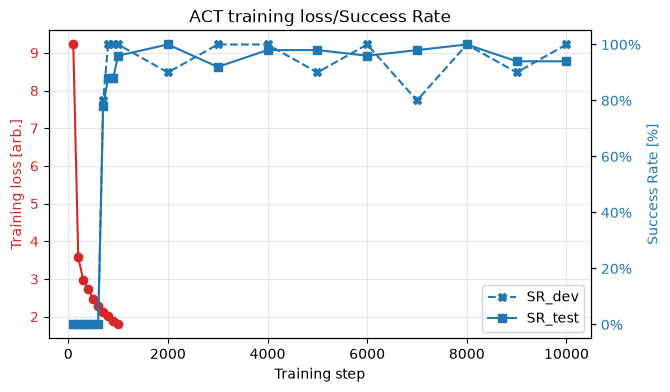

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = pd.read_csv(f"{MODEL_ROOT}/training_metrics.csv")

fig, ax1 = plt.subplots(figsize=(7, 4))
color = 'tab:red'
ax1.plot(metrics["step"], metrics["loss"], marker="o",color = color, label = "loss")
ax1.set_ylabel("Training loss [arb.]",color = color)
ax1.tick_params(axis='y', labelcolor=color)

ax1.set_xlabel("Training step")
ax1.set_title("ACT training loss/Success Rate")
ax1.grid(alpha=0.3)


ax2 = ax1.twinx()
color = 'tab:blue'
ax2.plot(df_agg.index, df_agg["success"], marker="X",color=color, linestyle = "--", label="SR_dev")
ax2.plot(df_test_agg.index, df_test_agg["success"], marker="s",color=color, label="SR_test")
ax2.set_ylabel('Success Rate [%]', color=color)  # we already handled the x-label with ax1
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yticks(ticks=[0,0.2,0.4,0.6,0.8,1.0],labels=["0%", "20%", "40%", "60%", "80%", "100%"])
ax2.legend()

plt.show()